# PLANTILLA EDA

**IMPORTANTE**: Recuerda hacer una copia de esta plantilla para no machacar la original.

## 1. IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

#Automcompletar rápido
%config IPCompleter.greedy=True

#Formato sin notación científica
pd.options.display.float_format = '{:15.2f}'.format 

## 2. IMPORTAR LOS DATOS

Sustituir la ruta del proyecto.

In [2]:
ruta_proyecto = 'C:/Users/Oscar/OneDrive - FM4/Escritorio/Python Data Mastery/EstructuraDirectorio/03_MACHINE_LEARNING/08_CASOS/007_AIRBNB'

Nombres de los ficheros de datos.

In [3]:
nombre_cat = 'cat_resultado_calidad.pickle'
nombre_num = 'num_resultado_calidad.pickle'

Cargar los datos.

In [4]:
cat = pd.read_pickle(ruta_proyecto + '/02_Datos/03_Trabajo/' + nombre_cat)
num = pd.read_pickle(ruta_proyecto + '/02_Datos/03_Trabajo/' + nombre_num)

## 3. EDA CATEGÓRICAS

### 3.1. Análisis estadístico

In [5]:
cat.columns.to_list()

['name',
 'host_response_time',
 'host_is_superhost',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'property_type',
 'room_type',
 'amenities',
 'has_availability',
 'license',
 'instant_bookable',
 'neighbourhood_group',
 'host_since',
 'first_review',
 'last_review',
 'bedrooms_disc',
 'accommodates_disc',
 'beds_disc',
 'number_of_reviews_disc']

In [6]:
incluir_cat = cat.columns.to_list()

#Eliminamos las columnas que estén en la siguiente lista
for i in sorted([0, 6, 8, 13, 14, 15], reverse=True):
    del incluir_cat[i]

In [7]:
def frecuencias_cat(cat):
    # Asegúrate de que todas las columnas son de tipo 'str' para evitar problemas de comparación
    cat = cat[incluir_cat]
    
    resultado = cat.apply(lambda x: x.value_counts(normalize = True))\
                .T.stack()\
                .to_frame().reset_index()\
                .rename(columns={'level_0':'Variable','level_1':'Valor',0: "Frecuencia"})\
                .sort_values(by = ['Variable','Frecuencia'])
    return resultado

In [8]:
cat[incluir_cat].info()

<class 'pandas.core.frame.DataFrame'>
Index: 18139 entries, 21853 to 1308864880309321118
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   host_response_time      18139 non-null  object
 1   host_is_superhost       18139 non-null  object
 2   host_verifications      18139 non-null  object
 3   host_has_profile_pic    18139 non-null  object
 4   host_identity_verified  18139 non-null  object
 5   room_type               18139 non-null  object
 6   has_availability        18139 non-null  object
 7   license                 18139 non-null  object
 8   instant_bookable        18139 non-null  object
 9   neighbourhood_group     18139 non-null  object
 10  bedrooms_disc           18139 non-null  object
 11  accommodates_disc       18139 non-null  object
 12  beds_disc               18139 non-null  object
 13  number_of_reviews_disc  18139 non-null  object
dtypes: object(14)
memory usage: 2.1+ MB


In [9]:
pd.set_option('display.max_rows', None)

frecuencias_cat(cat[incluir_cat])
#Aparecerá una lista de todas las variables con su frecuencia asociada

,Variable,Valor,Frecuencia
54,accommodates_disc,4-16,0.16
53,accommodates_disc,4,0.24
52,accommodates_disc,0-3,0.59
51,bedrooms_disc,04_Cuatro o mas,0.03
50,bedrooms_disc,03_Tres,0.07
47,bedrooms_disc,00_Estudio,0.15
49,bedrooms_disc,02_Dos,0.20
48,bedrooms_disc,01_Una,0.55
57,beds_disc,3-19,0.09
56,beds_disc,3,0.41


### 3.2. Análisis gráfico

In [10]:
def graficos_eda_categoricos(cat):
  
    # Filtrar solo columnas numéricas seleccionadas en incluir_num
    cat = cat[incluir_cat]

    # Verificar si hay columnas numéricas
    if cat.shape[1] == 0:
        print("No hay columnas categóricas para graficar.")
        return    
    #Calculamos el número de filas que necesitamos
    from math import ceil
    filas = ceil(cat.shape[1] / 2)

    #Definimos el gráfico
    f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

    #Aplanamos para iterar por el gráfico como si fuera de 1 dimensión en lugar de 2
    ax = ax.flat 

    #Creamos el bucle que va añadiendo gráficos
    for cada, variable in enumerate(cat):
        cat[variable].value_counts().plot.barh(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 12, fontweight = "bold")
        ax[cada].tick_params(labelsize = 12)

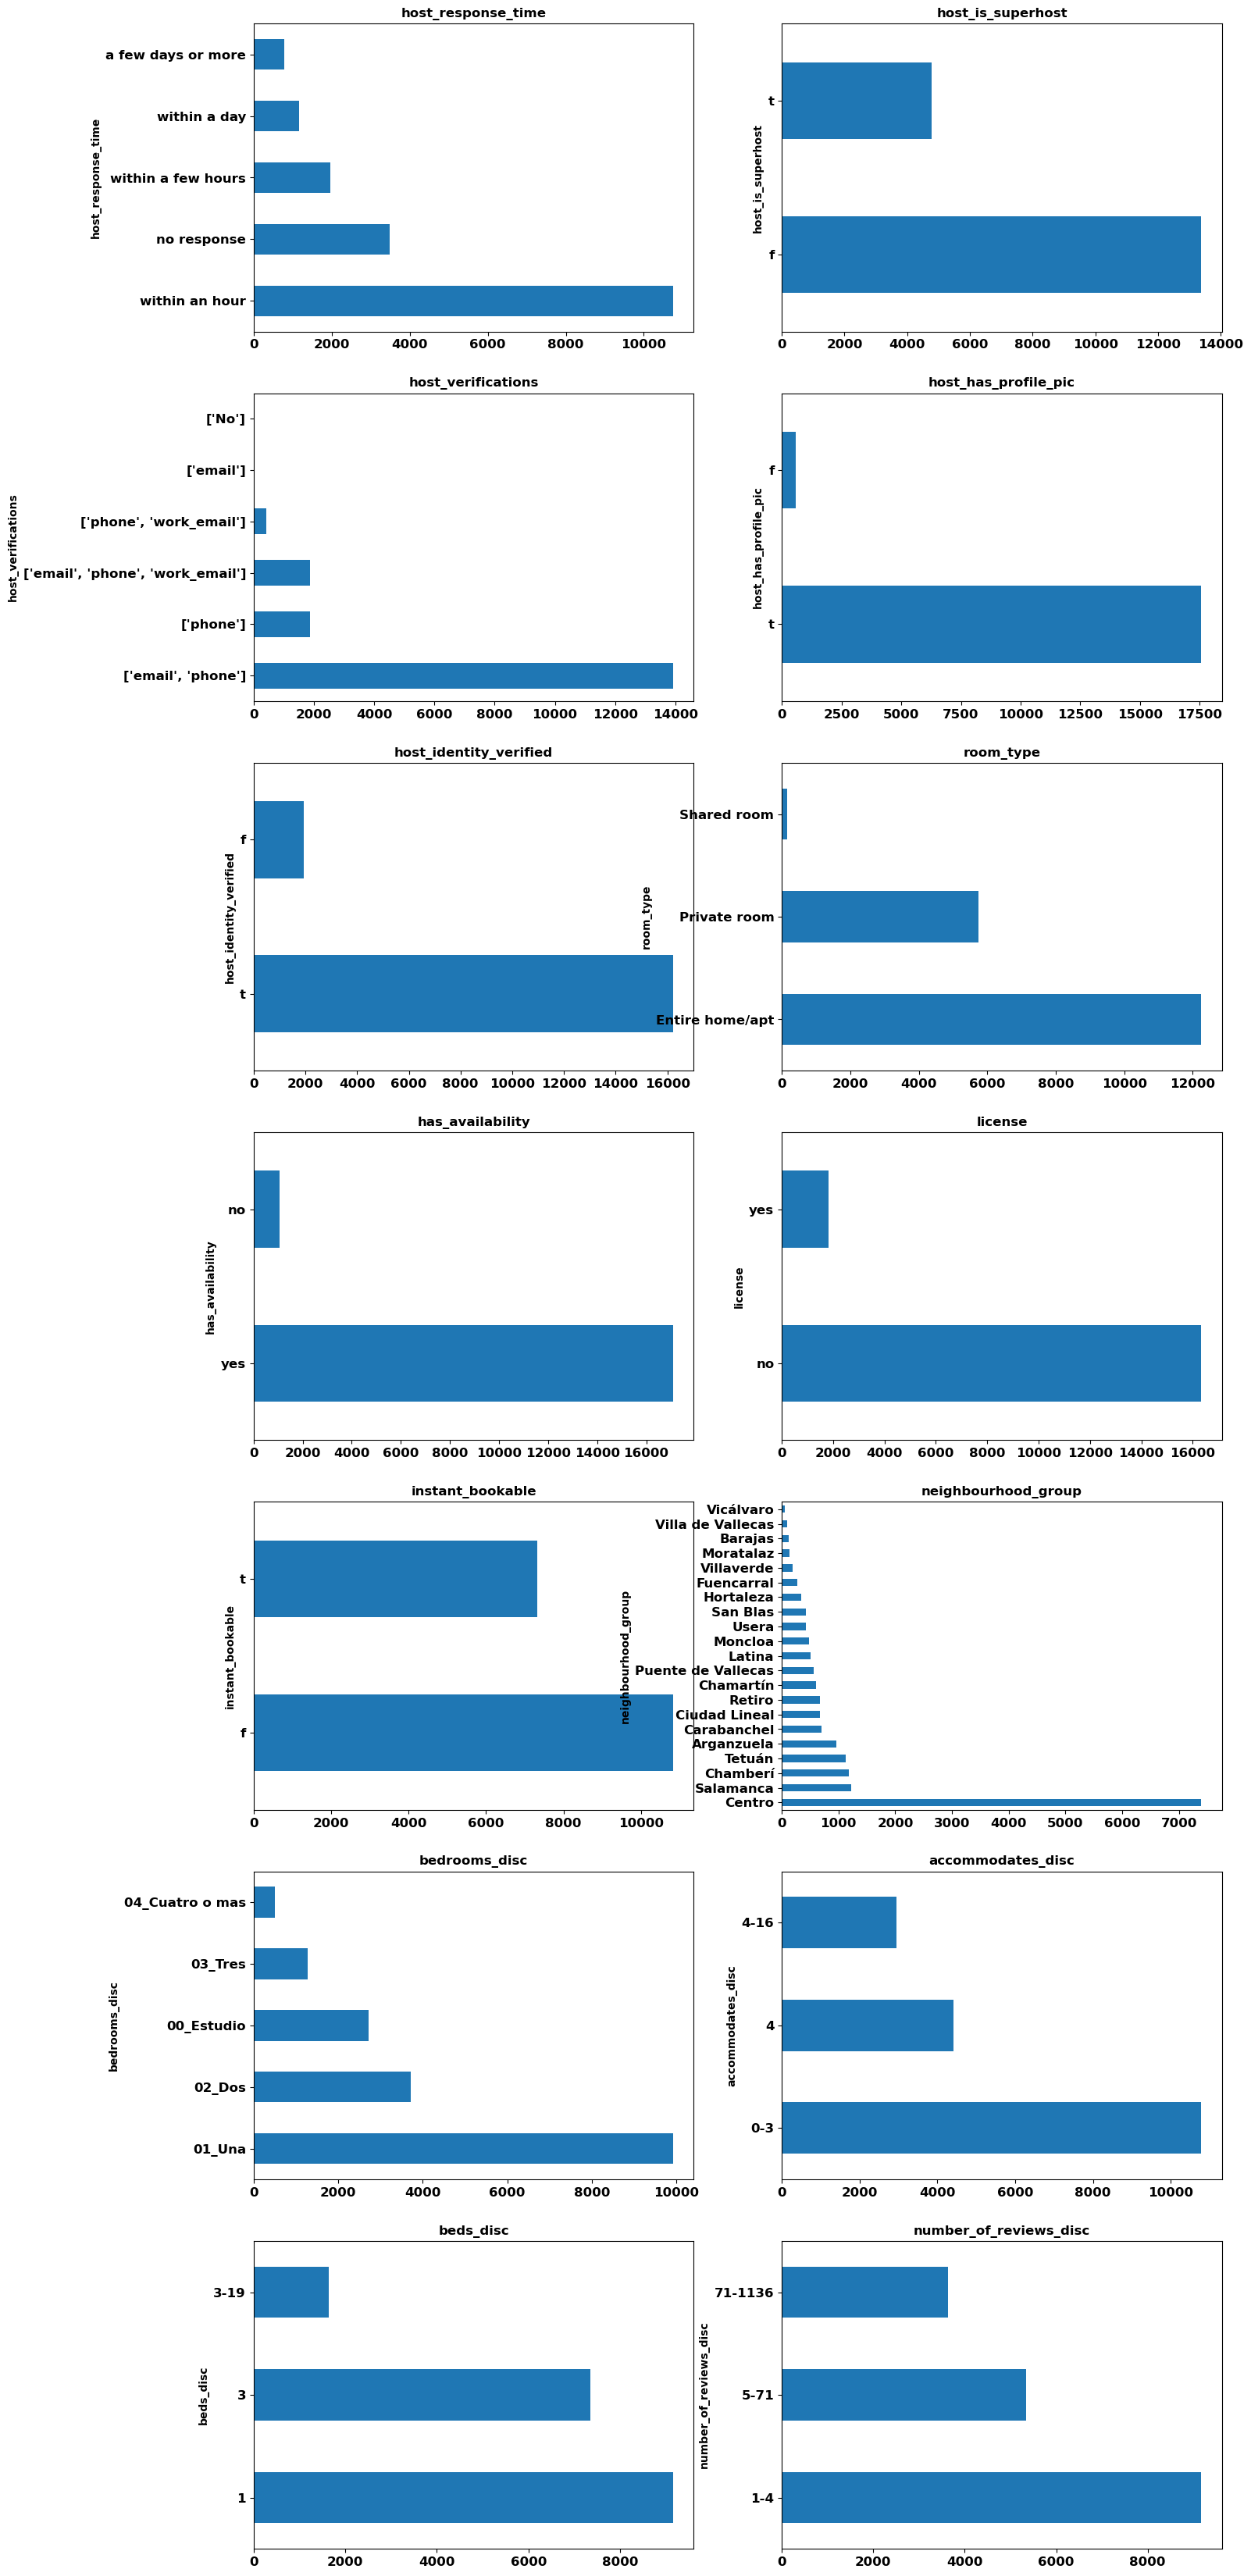

In [11]:
graficos_eda_categoricos(cat)

## 4. EDA NUMÉRICAS

### 4.1. Análisis estadístico

In [12]:
incluir_num = num.columns.to_list()

#Eliminamos las columnas que estén en la siguiente lista
for i in sorted([0], reverse=True):
    del incluir_num[i]

In [13]:
def estadisticos_cont(num):
    #Calculamos describe
    estadisticos = num.describe().T
    #Añadimos la mediana
    estadisticos['median'] = num.median()
    #Reordenamos para que la mediana esté al lado de la media
    estadisticos = estadisticos.iloc[:,[0,1,8,2,3,4,5,6,7]]
    #Lo devolvemos
    return(estadisticos)

In [14]:
num[incluir_num].info()

<class 'pandas.core.frame.DataFrame'>
Index: 18139 entries, 21853 to 1308864880309321118
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   host_id                                       18139 non-null  int64  
 1   host_response_rate                            18139 non-null  float64
 2   host_acceptance_rate                          18139 non-null  float64
 3   host_listings_count                           18139 non-null  float64
 4   host_total_listings_count                     18139 non-null  float64
 5   latitude                                      18139 non-null  float64
 6   longitude                                     18139 non-null  float64
 7   accommodates                                  18139 non-null  int64  
 8   bathrooms                                     18139 non-null  float64
 9   bedrooms                                      18

In [15]:
pd.set_option('display.max_rows', None)

estadisticos_cont(num[incluir_num])
#Aparecerá una lista de todas las variables con su frecuencia asociada

,count,mean,median,std,min,25%,50%,75%,max
host_id,18139.00,247862242.73,208980277.00,203475000.33,7952.00,48380095.00,208980277.00,440993833.00,666295558.00
host_response_rate,18139.00,74.59,100.00,40.75,0.00,65.00,100.00,100.00,100.00
host_acceptance_rate,18139.00,84.68,97.00,24.51,0.00,82.00,97.00,100.00,100.00
host_listings_count,18139.00,49.89,3.00,134.00,1.00,1.00,3.00,23.00,3251.00
host_total_listings_count,18139.00,61.09,5.00,189.92,1.00,2.00,5.00,30.00,7970.00
latitude,18139.00,40.42,40.42,0.02,40.33,40.41,40.42,40.43,40.53
longitude,18139.00,-3.69,-3.70,0.03,-3.83,-3.71,-3.70,-3.68,-3.55
accommodates,18139.00,3.16,3.00,1.89,1.00,2.00,3.00,4.00,16.00
bathrooms,18139.00,1.28,1.00,0.61,0.00,1.00,1.00,1.50,15.00
bedrooms,18139.00,1.30,1.00,0.98,0.00,1.00,1.00,2.00,12.00


### 4.2. Análisis gráfico

In [16]:
def graficos_eda_continuas(num):
    
    # Filtrar solo columnas numéricas seleccionadas en incluir_num
    num = num[incluir_num]

    # Verificar si hay columnas numéricas
    if num.shape[1] == 0:
        print("No hay columnas numéricas para graficar.")
        return
    
    #Calculamos el número de fila que necesitamos
    from math import ceil
    filas = ceil(num.shape[1] / 2)

    #Definimos el gráfico
    f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

    #Aplanamos para iterar por el gráfico como si fuera de 1 dimensión en lugar de 2
    ax = ax.flat 

    #Creamos el bucle que va añadiendo gráficos
    for cada, variable in enumerate(num):
        num[variable].plot.density(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 12, fontweight = "bold")
        ax[cada].tick_params(labelsize = 12)

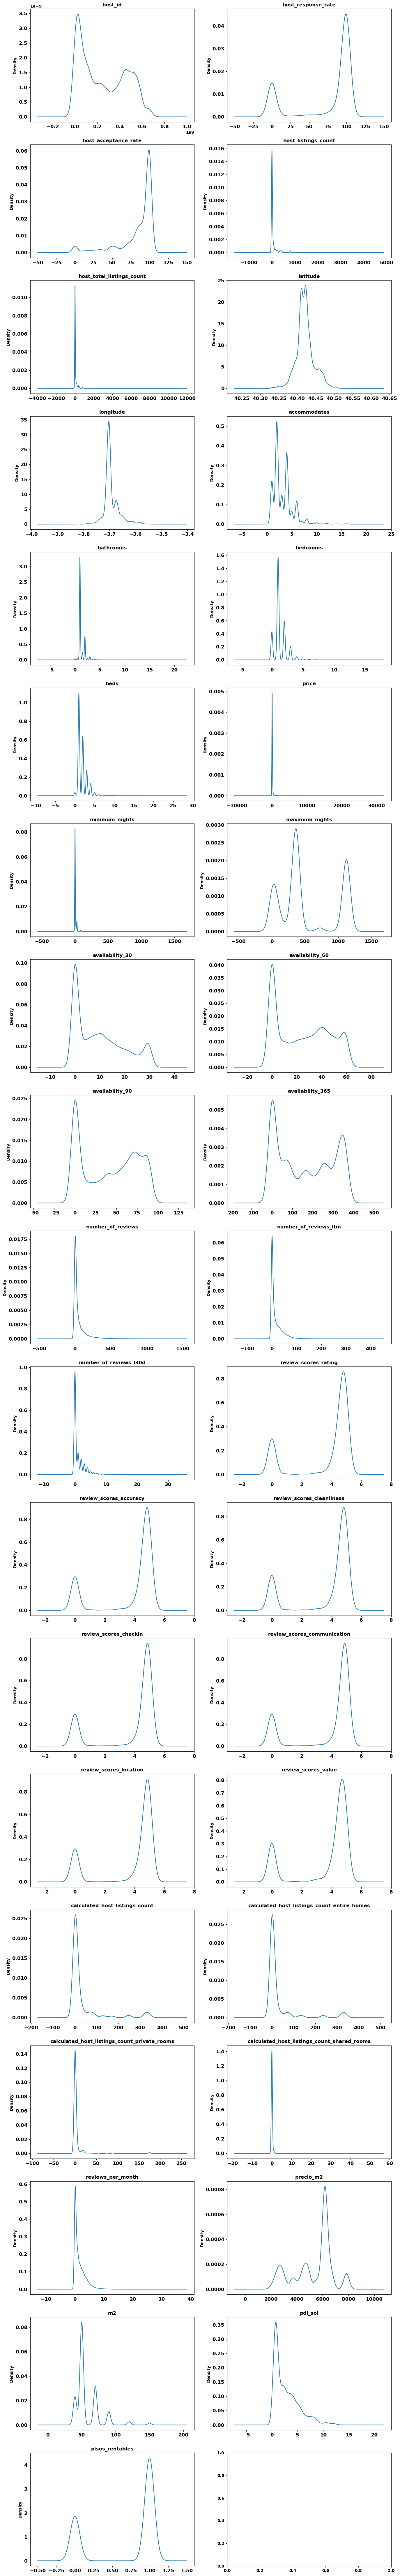

In [17]:
graficos_eda_continuas(num)

## 5. GUARDAR DATASETS TRAS CALIDAD DE DATOS

Guarda los avances en cat y num con un sufijo para poder guardar o recuperar avances del proyecto.

En formato pickle para no perder las modificaciones de metadatos.

*NOTA: En algunos casos no hay cambios en los ficheros en esta fase, así que este paso es opcional.Pero si no guardas estos ficheros acuérdate de modificar la importación en el siguiente notebook.*

In [18]:
#Definir los nombres de los archivos
ruta_cat = ruta_proyecto + '/02_Datos/03_Trabajo/' + 'cat_resultado_eda.pickle'
ruta_num = ruta_proyecto + '/02_Datos/03_Trabajo/' + 'num_resultado_eda.pickle'

In [19]:
#Guardar los archivos
cat.to_pickle(ruta_cat)
num.to_pickle(ruta_num)